# 02 — Data extraction: from showers to a handful of numbers per event

Each simulated event is a full electromagnetic shower — thousands of pixel hits.
To study energy resolution we reduce every event to **five numbers**, then save
them all to one small `.npz` (~350 KB) for the ML pipeline.

The reduction does two physics-motivated things:

1. **Isolates the entry module.** The photon enters one face of the 12-sided
   barrel. A shower is not fully contained — soft secondaries leak across the
   inner air cavity and strike *other* faces. Those hits are real, but they're an
   artifact of this closed test geometry, not a property of the calorimeter
   technology. A real measurement reads out the module the beam enters, so we
   keep only hits in the **+y 30° wedge** (one of the 12 segments) at the silicon
   radius.
2. **Applies a readout threshold.** A pixel only registers if its deposit clears
   a zero-suppression threshold (~½ MIP), exactly as a real chip would.

**Kernel**: `Python (Key4hep)` (CPU; I/O-bound).
**Output**: `$CALOMAPS_HOME/models/decal_extracted_data.npz`.

## 1. Parameters and detector geometry

The MIP scale (`MIP_ENERGY`) is the Landau most-probable energy deposit of a
minimum-ionizing particle in the silicon sensor. We read the 30 silicon layer
**radii** straight from the geometry XML so the layer assignment stays correct
even inside the tilted wedge.

In [1]:
import os, glob, xml.etree.ElementTree as ET
import numpy as np, uproot
from concurrent.futures import ProcessPoolExecutor, as_completed

CALOMAPS_HOME = os.environ.get("CALOMAPS_HOME", os.path.expanduser("~/CALOMAPS"))
DATA_BASE     = os.environ.get("CALOMAPS_DATA_BASE", os.path.expanduser("~/CALOMAPS-data"))
DATASET       = "data_spectrum_100um_400GeV"

CELL_SIZE  = 0.1            # mm — 100 um pixel pitch
MIP_ENERGY = 85e-6          # GeV — Landau MPV for the sensor
THRESHOLD  = 0.5 * MIP_ENERGY   # zero-suppression: a pixel "fires" above 1/2 MIP
NSIDES     = 12                 # dodecagonal barrel
SEG_HALF_DEG = 180.0 / NSIDES   # 15 deg half-wedge (one segment)
RMIN, RMAX = 1264.0, 1403.0     # silicon shell inner/outer radius [mm]

def _pv(v, c):
    # SiD XML value parser: cm->10mm, mm->1, recurse on constant names.
    if not v: return 0.0
    if v in c: return _pv(c[v], c)
    s = v.replace('*', ' * ').replace('cm', '10').replace('mm', '1')
    try: return float(eval(s, {"__builtins__": None}, {}))
    except Exception:
        try: return float(v)
        except Exception: return 0.0

def layer_radii():
    g = os.path.join(CALOMAPS_HOME, "geometry")
    consts = {x.get("name"): x.get("value")
              for x in ET.parse(os.path.join(g, "SiD_TestBeam.xml")).getroot().findall(".//constant")}
    det = ET.parse(os.path.join(g, "my_custom_ecal.xml")).getroot().find(".//detector[@name='ECalBarrel']")
    cur, planes = _pv(det.find("dimensions").get("rmin"), consts), []
    for layer in det.findall("layer"):
        rep = int(layer.get("repeat", 1)); sl = layer.findall("slice")
        thick = sum(_pv(s.get("thickness"), consts) for s in sl)
        off = sioff = 0.0
        for s in sl:
            t = _pv(s.get("thickness"), consts)
            if s.get("material") == "Silicon": sioff = off + t / 2
            off += t
        for _ in range(rep):
            planes.append(cur + sioff); cur += thick
    return np.array(planes)

RADII = layer_radii()
print(f"parsed {len(RADII)} silicon layers, r = [{RADII.min():.1f}, {RADII.max():.1f}] mm")

parsed 30 silicon layers, r = [1266.9, 1400.7] mm


## 2. The five numbers we keep per event

| variable | what it is | readout it models |
|---|---|---|
| `all_truth` | true photon energy `√(p²+m²)` | the label we want to recover |
| `all_visible` | Σ energy of all hits in the segment | **True Analog** (perfect charge sum) |
| `all_mip` | Σ over fired pixels of `round(E_pix/E_MIP)` | **MIP counting** (MIPs-per-pixel) |
| `all_hits` | number of pixels above ½-MIP threshold | **Raw Hits** (pure binary/digital) |
| `all_cluster` | number of 8-connected clusters, summed over layers | **Naive 2D Clustering** |

These form a ladder of readout sophistication. At low energy they all track the
energy linearly; at high energy the *digital* ones break down — pixels saturate
(one pixel hit by several particles still counts once), so **Hits** goes
sublinear and **Clustering** turns over as adjacent pixels merge. **Analog** and
**MIP** stay closest to linear. Quantifying that breakdown is the whole point of
the study.

## 3. Per-file worker

For each event: keep hits in the +y wedge, assign each to its nearest silicon
layer by radius, then compute the five numbers. Clustering uses an 8-connected
flood-fill on the pixel grid (identical to `DBSCAN(eps=1.5·pitch, min_samples=1)`
but O(n), so it doesn't blow up on dense high-energy layers).

In [2]:
def naive_clusters(x, z, layer_idx, e):
    # 8-connected components per layer, summed. Two fired pixels join a cluster
    # iff they are adjacent (incl. diagonally) on the 100 um grid.
    m = e > THRESHOLD
    if not m.any():
        return 0
    xi = np.round(x[m] / CELL_SIZE).astype(np.int64)
    zi = np.round(z[m] / CELL_SIZE).astype(np.int64)
    li = layer_idx[m]
    total = 0
    for ly in np.unique(li):
        sel = li == ly
        cells_ = set(zip(xi[sel].tolist(), zi[sel].tolist()))
        seen = set()
        for c0 in cells_:
            if c0 in seen:
                continue
            total += 1
            stack = [c0]
            while stack:
                ux, uz = stack.pop()
                if (ux, uz) in seen:
                    continue
                seen.add((ux, uz))
                for dx in (-1, 0, 1):
                    for dz in (-1, 0, 1):
                        v = (ux + dx, uz + dz)
                        if v in cells_ and v not in seen:
                            stack.append(v)
    return total

def process_single_file(filepath):
    br = ["ECalBarrelHits.position.x", "ECalBarrelHits.position.y",
          "ECalBarrelHits.position.z", "ECalBarrelHits.energy",
          "MCParticles.momentum.x", "MCParticles.momentum.y",
          "MCParticles.momentum.z", "MCParticles.mass"]
    T, V, M, H, C = [], [], [], [], []
    try:
        with uproot.open(filepath) as f:
            tr = f["events"]
            if tr.num_entries == 0:
                return None
            a = tr.arrays(br)
            truth = np.sqrt(a["MCParticles.momentum.x"][:, 0]**2 +
                            a["MCParticles.momentum.y"][:, 0]**2 +
                            a["MCParticles.momentum.z"][:, 0]**2 +
                            a["MCParticles.mass"][:, 0]**2)
            hx, hy = a["ECalBarrelHits.position.x"], a["ECalBarrelHits.position.y"]
            hz, he = a["ECalBarrelHits.position.z"], a["ECalBarrelHits.energy"]
            for ev in range(len(he)):
                x = np.asarray(hx[ev]); y = np.asarray(hy[ev])
                z = np.asarray(hz[ev]); e = np.asarray(he[ev])
                if len(e) == 0:
                    continue
                r = np.hypot(x, y)
                ang = np.degrees(np.arctan2(x, y))           # angle from +y in x-y plane
                seg = (np.abs(ang) < SEG_HALF_DEG) & (r > RMIN - 4) & (r < RMAX + 14)
                x, z, e, r = x[seg], z[seg], e[seg], r[seg]
                if len(e) == 0:
                    continue
                layer_idx = np.argmin(np.abs(RADII[None, :] - r[:, None]), axis=1)
                thr = e > THRESHOLD
                T.append(float(truth[ev]))
                V.append(float(e.sum()))                                       # analog
                M.append(float(np.maximum(1, np.round(e[thr] / MIP_ENERGY)).sum()))  # MIPs/pixel
                H.append(int(thr.sum()))                                        # binary hits
                C.append(naive_clusters(x, z, layer_idx, e))                    # clusters
    except Exception as ex:
        print(f"  failed {os.path.basename(filepath)}: {ex}")
        return None
    return T, V, M, H, C

## 4. Run the extraction in parallel and save

Forks a process pool over the ~889 files. With the grid clustering this is
I/O-bound and finishes in well under a couple of minutes.

In [3]:
file_list = sorted(glob.glob(os.path.join(DATA_BASE, DATASET, "sim_photons_part*.root")))
print(f"Found {len(file_list)} files. Extracting...")

all_truth, all_visible, all_mip, all_hits, all_cluster = [], [], [], [], []
with ProcessPoolExecutor(max_workers=min(32, os.cpu_count() or 8)) as ex:
    futures = {ex.submit(process_single_file, f): f for f in file_list}
    for n, fut in enumerate(as_completed(futures), 1):
        r = fut.result()
        if r:
            all_truth += r[0]; all_visible += r[1]; all_mip += r[2]
            all_hits += r[3]; all_cluster += r[4]
        if n % 100 == 0:
            print(f"  {n}/{len(file_list)}")

all_truth   = np.array(all_truth)
all_visible = np.array(all_visible, dtype=np.float32)
all_mip     = np.array(all_mip, dtype=np.float32)
all_hits    = np.array(all_hits, dtype=np.int64)
all_cluster = np.array(all_cluster, dtype=np.int64)

out_dir = os.path.join(CALOMAPS_HOME, "models"); os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "decal_extracted_data.npz")
np.savez_compressed(out_path, all_truth=all_truth, all_visible=all_visible,
                    all_mip=all_mip, all_hits=all_hits, all_cluster=all_cluster)
print(f"\nExtracted {len(all_truth)} events -> {out_path} ({os.path.getsize(out_path)/1024:.0f} KB)")

Found 889 files. Extracting...


  100/889


  200/889


  300/889


  400/889


  500/889


  600/889


  700/889


  800/889



Extracted 17780 events -> /nashome/m/murtazas/CALOMAPS/models/decal_extracted_data.npz (334 KB)


## 5. The raw readout distributions

Plot each readout against true energy. The dashed line is a straight fit to the
**low-energy** region (< 50 GeV), extrapolated across the full range — so any
**deviation at high energy is the digital breakdown**:

- **Analog / MIP** stay close to the line (energy- and MIP-proportional).
- **Raw Hits** droops below it — *pixel saturation*: above ~100 GeV the shower
  core puts several particles through the same 100 µm pixel, but a binary pixel
  can only say "hit once".
- **Clustering** turns over even harder — dense cores merge adjacent pixels into
  a few big blobs, so the *count* of clusters stops growing.

The vertical scatter at fixed energy is the **intrinsic resolution** of each
readout — exactly what the quantile ensembles in
[`03_ml_training_and_eval.ipynb`](03_ml_training_and_eval.ipynb) learn.

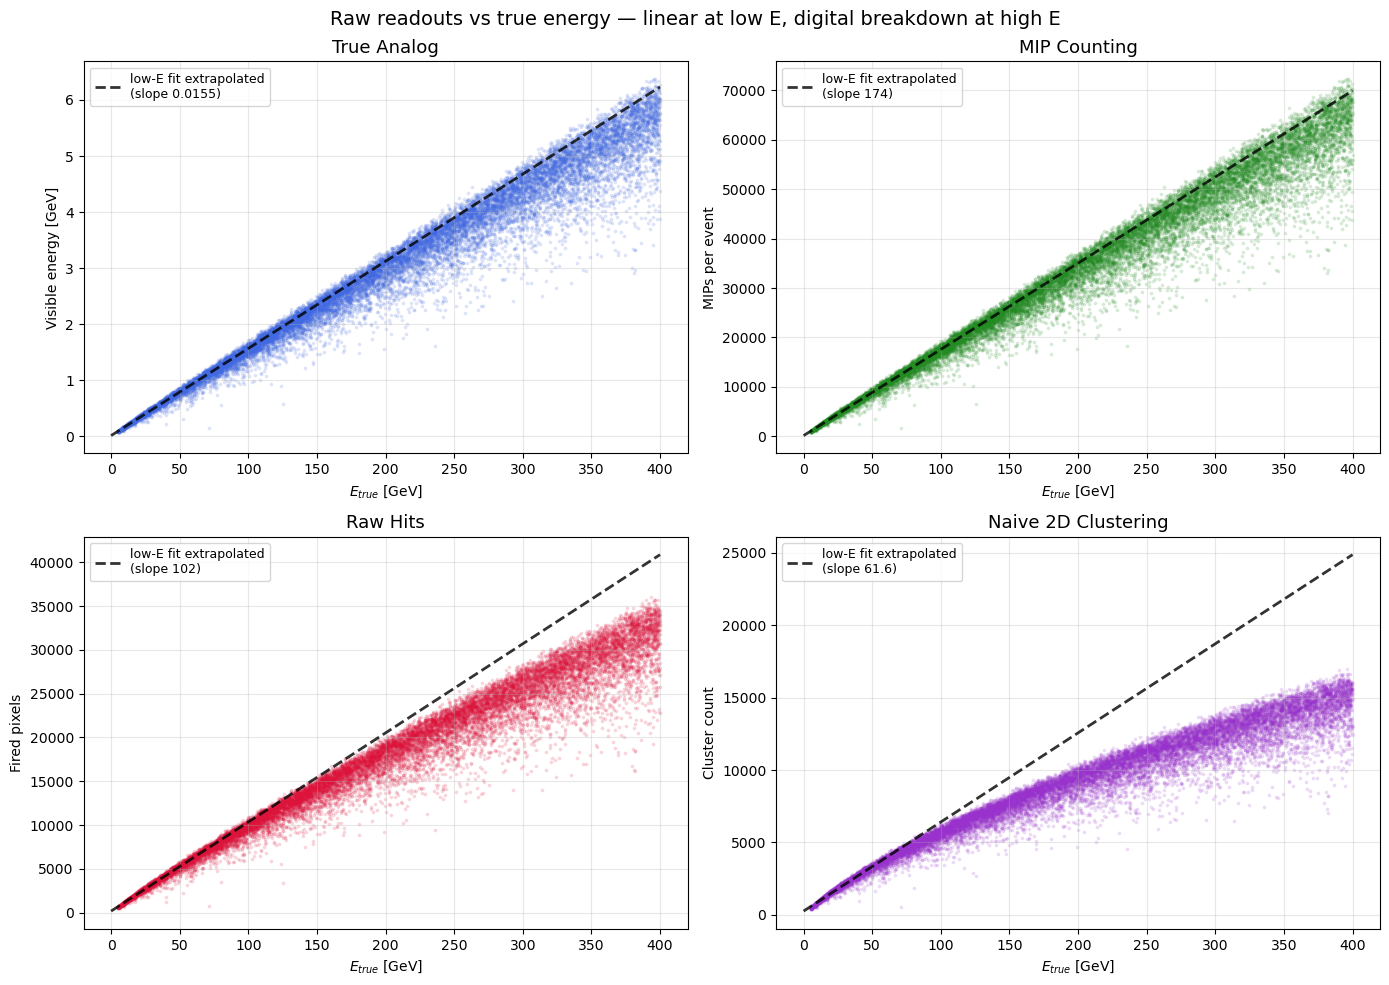

In [4]:
import matplotlib.pyplot as plt

panels = [("True Analog", all_visible, "royalblue", "Visible energy [GeV]"),
          ("MIP Counting", all_mip, "forestgreen", "MIPs per event"),
          ("Raw Hits", all_hits, "crimson", "Fired pixels"),
          ("Naive 2D Clustering", all_cluster, "darkorchid", "Cluster count")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, y, col, ylab) in zip(axes.flat, panels):
    good = (all_truth > 0) & (y > 0)
    t, yy = all_truth[good], y[good].astype(float)
    ax.scatter(t, yy, s=3, alpha=0.12, color=col)
    lo = t < 50
    if lo.sum() > 10:
        m, c = np.polyfit(t[lo], yy[lo], 1)
        xl = np.array([0, t.max()])
        ax.plot(xl, m * xl + c, "k--", lw=2, alpha=0.8,
                label=f"low-E fit extrapolated\n(slope {m:.3g})")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("$E_{true}$ [GeV]"); ax.set_ylabel(ylab)
    ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("Raw readouts vs true energy — linear at low E, digital breakdown at high E", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Why a *quantile* model? The response is a distribution

At any fixed true energy a readout doesn't give one value — it gives a spread
(shower-to-shower fluctuations). Below is the distribution of one readout in a
narrow energy slice. Its **width sets the resolution**, and it isn't necessarily
Gaussian — which is why the surrogate learns three *quantiles* (median ± 1σ)
rather than assuming a mean and a symmetric error.

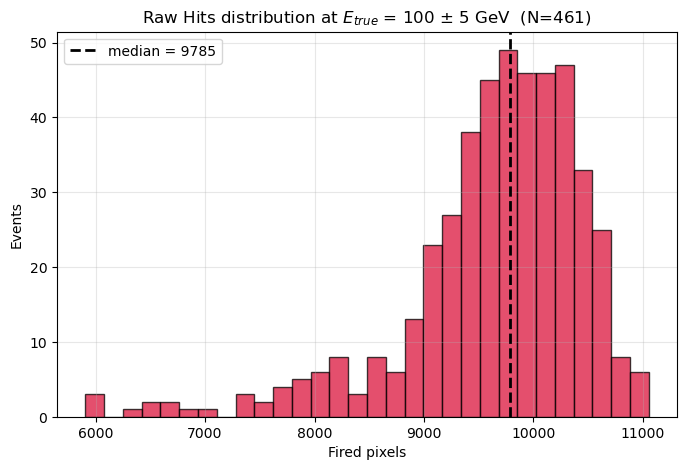

In [5]:
E0, dE = 100.0, 5.0
sl = np.abs(all_truth - E0) < dE
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_hits[sl], bins=30, color="crimson", alpha=0.75, edgecolor="black")
med = np.median(all_hits[sl])
ax.axvline(med, color="black", lw=2, ls="--", label=f"median = {med:.0f}")
ax.set_title(f"Raw Hits distribution at $E_{{true}}$ = {E0:.0f} $\\pm$ {dE:.0f} GeV  (N={sl.sum()})")
ax.set_xlabel("Fired pixels"); ax.set_ylabel("Events")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

Done. The five-number summary is saved. Next:
[`03_ml_training_and_eval.ipynb`](03_ml_training_and_eval.ipynb) trains a Deep
Quantile Ensemble on each readout and runs the Neyman-inversion reconstruction.